# Analyse Exploratoire

### Import des modules

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import missingno as msno
import numpy as np
import folium

### Analyse Exploratoire

In [3]:
building_consumption = pd.read_csv("data/2016_Building_Energy_Benchmarking.csv")

In [4]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


# On regarde le remplissage de chaque colonne

In [5]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
total = building_consumption.isnull().sum().sort_values(ascending=False)
percent = (building_consumption.isnull().sum()/building_consumption.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(40)
#delete Comments Outlier  YearsENERGYSTARCertified

,Total,Percent
Comments,3376,1.000000
Outlier,3344,0.990521
YearsENERGYSTARCertified,3257,0.964751
ThirdLargestPropertyUseType,2780,0.823460
ThirdLargestPropertyUseTypeGFA,2780,0.823460
SecondLargestPropertyUseType,1697,0.502666
SecondLargestPropertyUseTypeGFA,1697,0.502666
ENERGYSTARScore,843,0.249704
LargestPropertyUseTypeGFA,20,0.005924
LargestPropertyUseType,20,0.005924


### la librairie misingno permet de visualisé le remplissage des colonnes

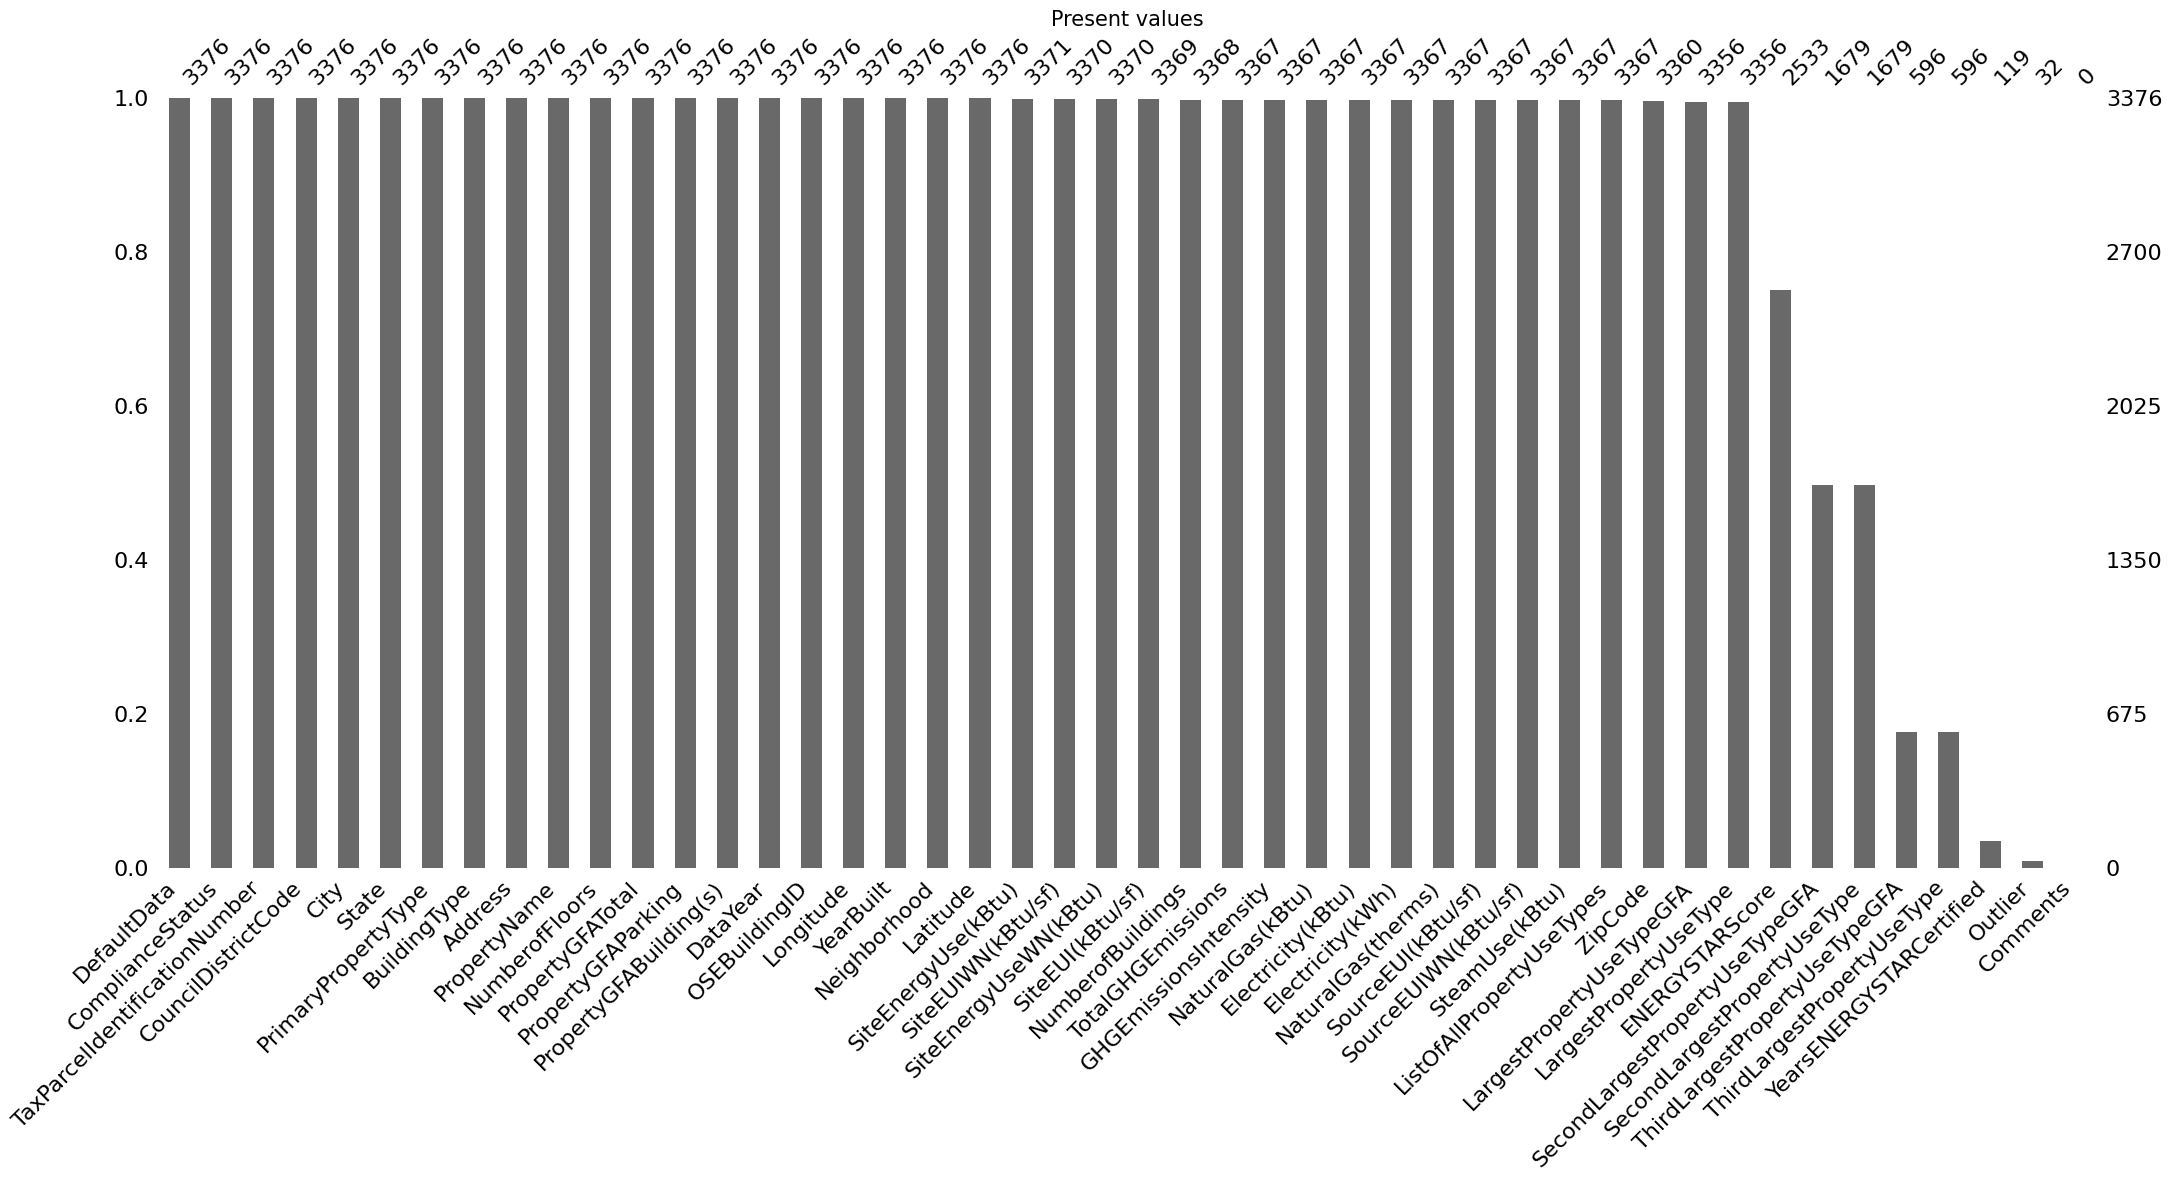

In [6]:


barchart = msno.bar(building_consumption, sort="descending")
barchart.set_title("Present values", fontsize=15)
plt.show()

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

### On verifie que les id sont bien unique

In [7]:
#on verifie que les ID soit bien unique dans le dataset
print(building_consumption["OSEBuildingID"].is_unique)
print(building_consumption["TaxParcelIdentificationNumber"].is_unique) # attention ce n'est pas unique donc voir pour supprimé les doublons
building_consumption['BuildingType'].unique()


#remove residential area
building_consumption.drop(building_consumption[building_consumption['BuildingType'] == 'Multifamily MR (5-9)'].index, inplace=True)
building_consumption.drop(building_consumption[building_consumption['BuildingType'] == 'Multifamily LR (1-4)'].index, inplace=True)
building_consumption.drop(building_consumption[building_consumption['BuildingType'] == 'Multifamily HR (10+)'].index, inplace=True)
building_consumption['BuildingType'].unique()


True
False


array(['NonResidential', 'Nonresidential COS', 'SPS-District K-12',
       'Campus', 'Nonresidential WA'], dtype=object)

### Création de la colonne age, qui regroupe l'année du relevé et l'année de construction

/tmp/user/1000/ipykernel_16333/4199896081.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age', data=building_consumption, palette=['#432371',"#FAAE7B"])
/tmp/user/1000/ipykernel_16333/4199896081.py:6: UserWarning: 
The palette list has fewer values (2) than needed (113) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='Age', data=building_consumption, palette=['#432371',"#FAAE7B"])


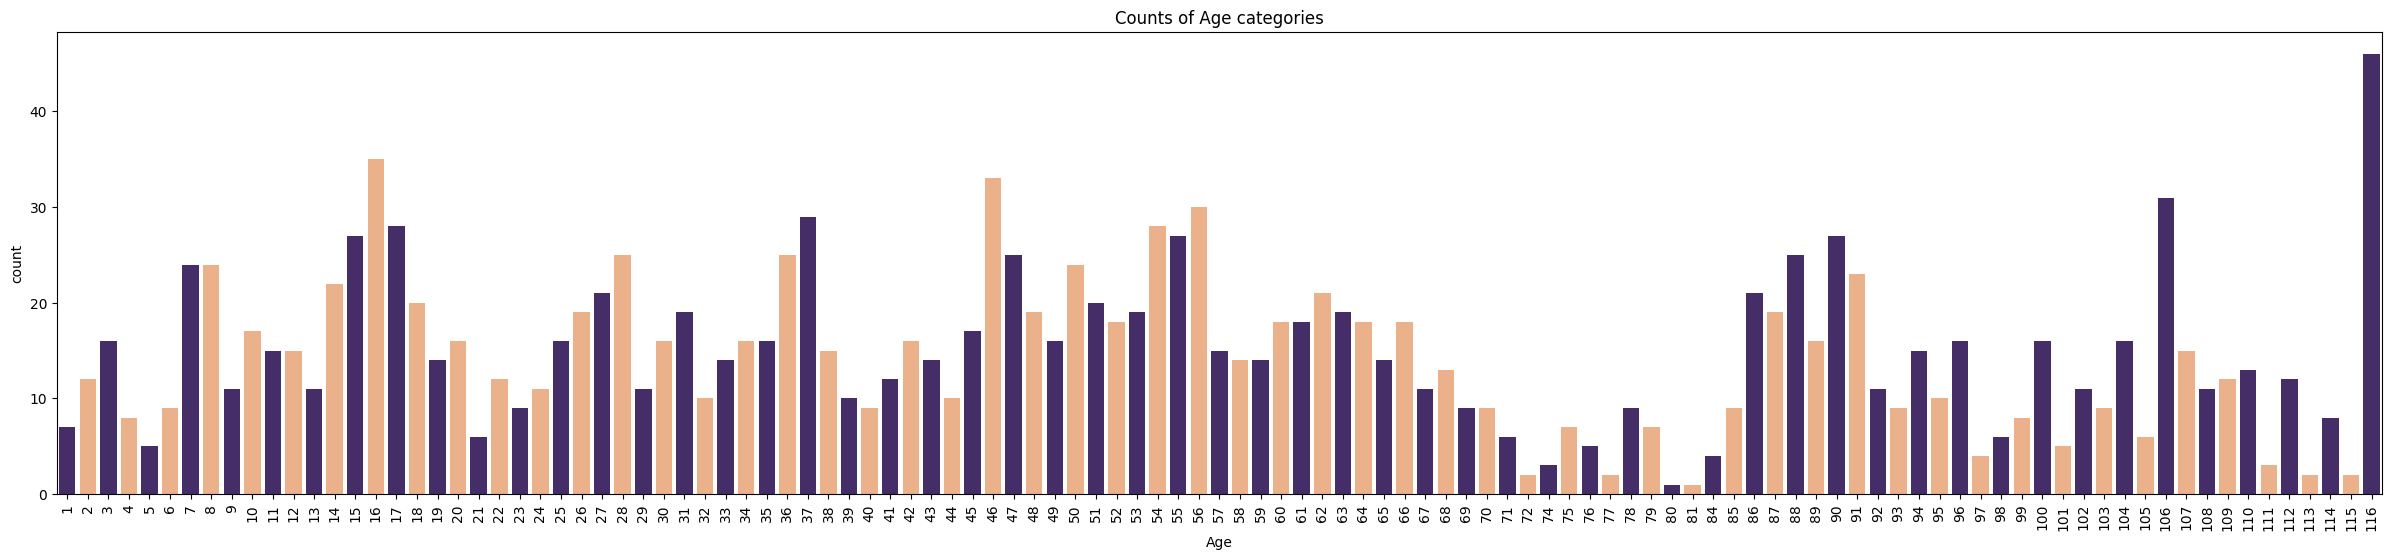

In [8]:
building_consumption["Age"] = building_consumption['DataYear'] - building_consumption["YearBuilt"]


plt.figure(figsize=(30,6))
plt.title("Counts of Age categories")
sns.countplot(x='Age', data=building_consumption, palette=['#432371',"#FAAE7B"])
plt.xticks(rotation=90)
plt.show()



### Comparaison des colonnes "énergie" via une matrice de correlation

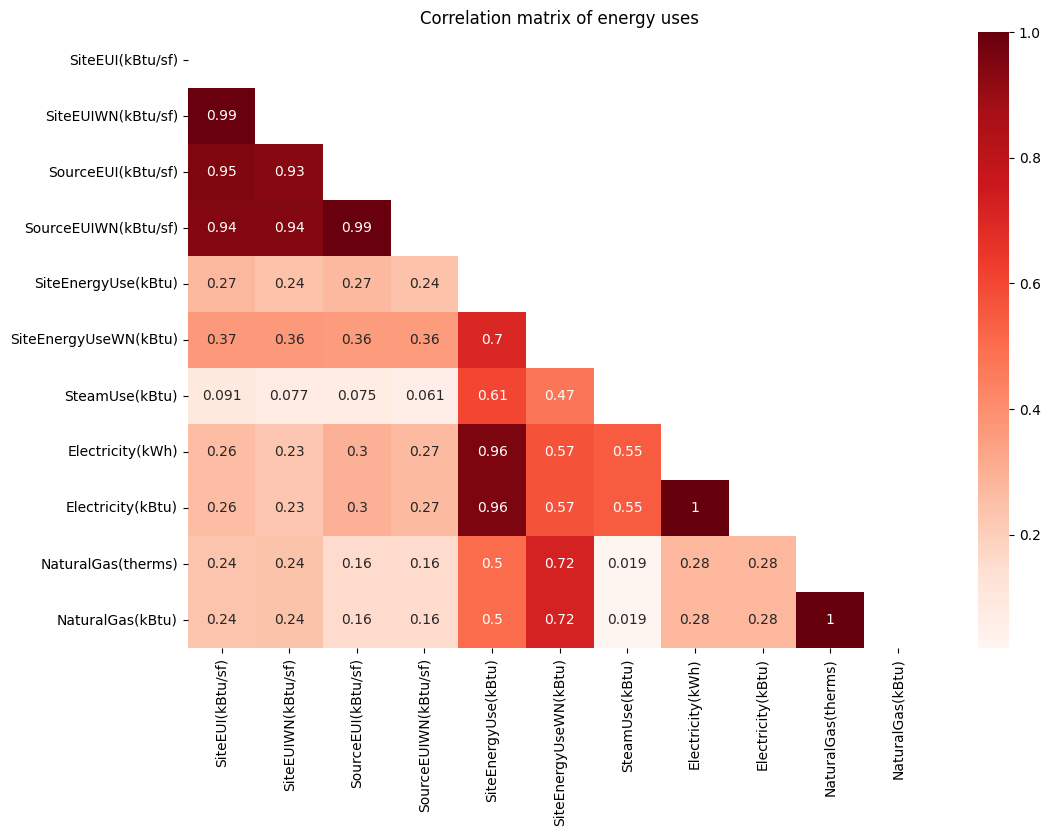

In [9]:
energy_columns = ['SiteEUI(kBtu/sf)', 
                'SiteEUIWN(kBtu/sf)', 
                'SourceEUI(kBtu/sf)', 
                'SourceEUIWN(kBtu/sf)',
                'SiteEnergyUse(kBtu)', 
                'SiteEnergyUseWN(kBtu)', 
                'SteamUse(kBtu)', 
                'Electricity(kWh)', 
                'Electricity(kBtu)', 
                'NaturalGas(therms)', 
                'NaturalGas(kBtu)']

corr = building_consumption[energy_columns].corr()

# Heatmap
plt.figure(figsize=(12,8))
plt.title("Correlation matrix of energy uses")
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr.abs(), mask=mask, cmap='Reds', annot=True)
plt.show()

### Suppression des lignes qui ne comportent ni batiment, ni étages

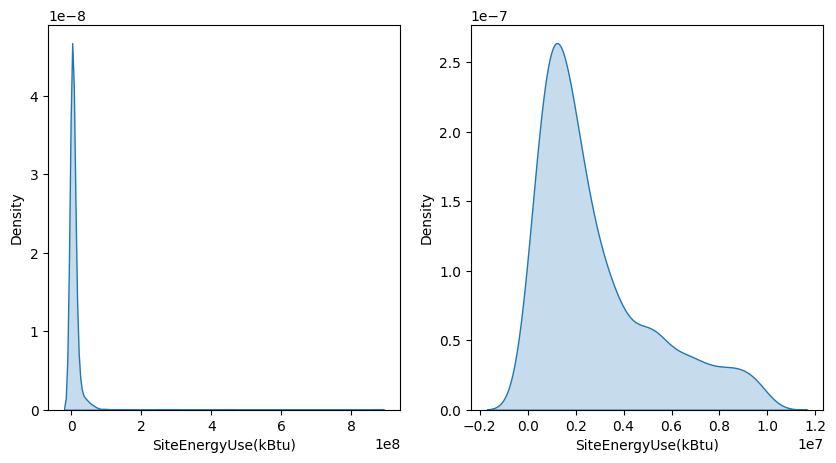

In [10]:
th = 1e7
fig, axes = plt.subplots(1,2,figsize=(10,5))
_ = sns.kdeplot(x="SiteEnergyUse(kBtu)", data=building_consumption, ax=axes[0], fill=True)
_ = sns.kdeplot(x="SiteEnergyUse(kBtu)", data=building_consumption[building_consumption["SiteEnergyUse(kBtu)"]<=th], ax=axes[1], fill=True)

In [11]:
building_consumption.drop(building_consumption[building_consumption['NumberofBuildings'] <= 0].index, inplace=True)
building_consumption.drop(building_consumption[building_consumption['NumberofFloors'] <= 0].index, inplace=True)
building_consumption.drop(building_consumption[building_consumption['SiteEnergyUse(kBtu)'] >= th].index, inplace=True)
building_consumption.drop(building_consumption[building_consumption['SiteEnergyUse(kBtu)'] <= 0].index, inplace=True)

### On créé 3 nouvelle colonnes qui represente si un type d'energie est utiliser ou non dans un batiment donner

In [12]:
building_consumption["use_electricity"] = np.where(building_consumption['Electricity(kWh)'] == 0, 0, 1)
building_consumption["use_steam"] = np.where(building_consumption['SteamUse(kBtu)'] == 0, 0, 1)
building_consumption["use_natural_gas"] = np.where(building_consumption['NaturalGas(kBtu)'] == 0, 0, 1)

### Création d'un fonction qui permet de savoir quelle source d'énergie est la plus utilisée

On appliquera la fonction a au dataframe pour créé notre nouvelle colonne

In [13]:
def compare_values(row):
    max_value = max(row['Electricity(kBtu)'], row['SteamUse(kBtu)'], row['NaturalGas(kBtu)'])
    if max_value == row['Electricity(kBtu)']:
        return 'electricity'
    elif max_value == row['SteamUse(kBtu)']:
        return 'steam'
    else:
        return 'natural_gas'

building_consumption['main_power_source'] = building_consumption.apply(compare_values, axis=1) # ne pas oublier de l'encoder apres 


### On enlève les valeur qui ne sont pas Compliant (Conforme de ma compréhension) et les Outlier (Données aberrante)

In [14]:
building_consumption.drop(building_consumption[building_consumption['ComplianceStatus'] != "Compliant"].index, inplace=True)
building_consumption.drop(building_consumption[
    building_consumption['Outlier'].notnull()].index, inplace=True)

#une fois la colonne "clean" on la drop, il n'y a aucune info utile dedans 

### Création d'un map interactive avec tout les batiments

> Soucis d'affichagedans le notebook, sauvegarde du resultat dans un fichier HTML

In [15]:
m = folium.Map((47.5236, -122.6750), tiles="cartodb positron")

for index, row in building_consumption.iterrows():
    folium.Marker(
        location=[row["Latitude"],row["Longitude"]],
        tooltip=row['PropertyName'],
        popup=row['PropertyName'],
        icon=folium.Icon(icon="cloud"),
    ).add_to(m)
m.save("map_1.html")

In [16]:
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,Age,use_electricity,use_steam,use_natural_gas,main_power_source
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,NaN,Compliant,NaN,249.98,2.83,89,1,1,1,electricity
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,NaN,Compliant,NaN,295.86,2.86,20,1,0,1,natural_gas
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,NaN,Compliant,NaN,286.43,4.67,90,1,1,1,electricity
6,10,2016,NonResidential,Hotel,Camlin,1619 9th Avenue,Seattle,WA,98101.0,0660000825,...,NaN,Compliant,NaN,176.14,2.12,90,1,0,1,natural_gas
7,11,2016,NonResidential,Other,Paramount Theatre,911 Pine St,Seattle,WA,98101.0,0660000955,...,NaN,Compliant,NaN,221.51,2.16,90,1,1,1,electricity


# Modélisation 

### Import des modules 

In [17]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [18]:
# CODE FEATURE ENGINEERING
column_drop = ['DataYear',
               'OSEBuildingID',
               'PropertyName',
               'Address', 
               'City', 
               'State',
               'ZipCode',
               'CouncilDistrictCode',
               'Latitude',
               'Longitude',
               'ENERGYSTARScore',
               'ListOfAllPropertyUseTypes',
               'SecondLargestPropertyUseType',
               'SecondLargestPropertyUseTypeGFA',
               'ThirdLargestPropertyUseType',
               'ThirdLargestPropertyUseTypeGFA',
               'YearsENERGYSTARCertified',
               'Comments', 
               'TaxParcelIdentificationNumber', 
               'YearBuilt',
               'ComplianceStatus',
               'Outlier',
               'SiteEUI(kBtu/sf)', 
               'SiteEUIWN(kBtu/sf)', 
               'SourceEUI(kBtu/sf)', 
               'SourceEUIWN(kBtu/sf)',
               #'SiteEnergyUse(kBtu)', 
               'SiteEnergyUseWN(kBtu)', 
               'SteamUse(kBtu)', 
               'Electricity(kWh)', 
               'Electricity(kBtu)', 
               'NaturalGas(therms)', 
               'NaturalGas(kBtu)'
               ]
building_consumption_w_drop = building_consumption.drop(column_drop, axis=1)

In [19]:
building_consumption_w_drop.head()

,BuildingType,PrimaryPropertyType,Neighborhood,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),DefaultData,TotalGHGEmissions,GHGEmissionsIntensity,Age,use_electricity,use_steam,use_natural_gas,main_power_source
0,NonResidential,Hotel,DOWNTOWN,1.0,12,88434,0,88434,Hotel,88434.0,7226362.5,False,249.98,2.83,89,1,1,1,electricity
1,NonResidential,Hotel,DOWNTOWN,1.0,11,103566,15064,88502,Hotel,83880.0,8387933.0,False,295.86,2.86,20,1,0,1,natural_gas
3,NonResidential,Hotel,DOWNTOWN,1.0,10,61320,0,61320,Hotel,61320.0,6794584.0,False,286.43,4.67,90,1,1,1,electricity
6,NonResidential,Hotel,DOWNTOWN,1.0,11,83008,0,83008,Hotel,81352.0,5758795.0,False,176.14,2.12,90,1,0,1,natural_gas
7,NonResidential,Other,DOWNTOWN,1.0,8,102761,0,102761,Other - Entertainment/Public Assembly,102761.0,6298131.5,False,221.51,2.16,90,1,1,1,electricity


In [20]:
print(len(pd.unique(building_consumption_w_drop["Neighborhood"])))
print(len(pd.unique(building_consumption_w_drop["BuildingType"])))
print(len(pd.unique(building_consumption_w_drop["PrimaryPropertyType"])))
print(len(pd.unique(building_consumption_w_drop["LargestPropertyUseType"])))

19
5
20
49


In [21]:
def encode_column_with_onehot(df, column_name, max_categories=100):
    # Initialiser le OneHotEncoder
    if column_name not in df.columns:
        print(f"La colonne '{column_name}' n'existe pas dans le DataFrame.")
        return df  # Retourner le DataFrame original sans modification
    encoder = OneHotEncoder(sparse_output=False, drop='first', max_categories=max_categories)  # drop='first' pour éviter la multicolinéarité
    # Appliquer l'encodage sur la colonne spécifiée
    encoded_array = encoder.fit_transform(df[[column_name]])
    # Récupérer les noms des colonnes encodées
    encoded_cols = encoder.get_feature_names_out([column_name])
    # Créer un DataFrame avec les colonnes encodées
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
    # Supprimer la colonne originale
    df = df.drop(columns=[column_name])
    # Concaténer le DataFrame original avec les colonnes encodées
    df_final = pd.concat([df, df_encoded], axis=1)
    return df_final


building_consumption_w_drop = encode_column_with_onehot(building_consumption_w_drop, "Neighborhood")
building_consumption_w_drop = encode_column_with_onehot(building_consumption_w_drop, "BuildingType")
building_consumption_w_drop = encode_column_with_onehot(building_consumption_w_drop, "PrimaryPropertyType")
building_consumption_w_drop = encode_column_with_onehot(building_consumption_w_drop, "LargestPropertyUseType")
building_consumption_w_drop = encode_column_with_onehot(building_consumption_w_drop, "main_power_source")
building_consumption_w_drop.head()
print(building_consumption.NumberofBuildings.max())

6.0


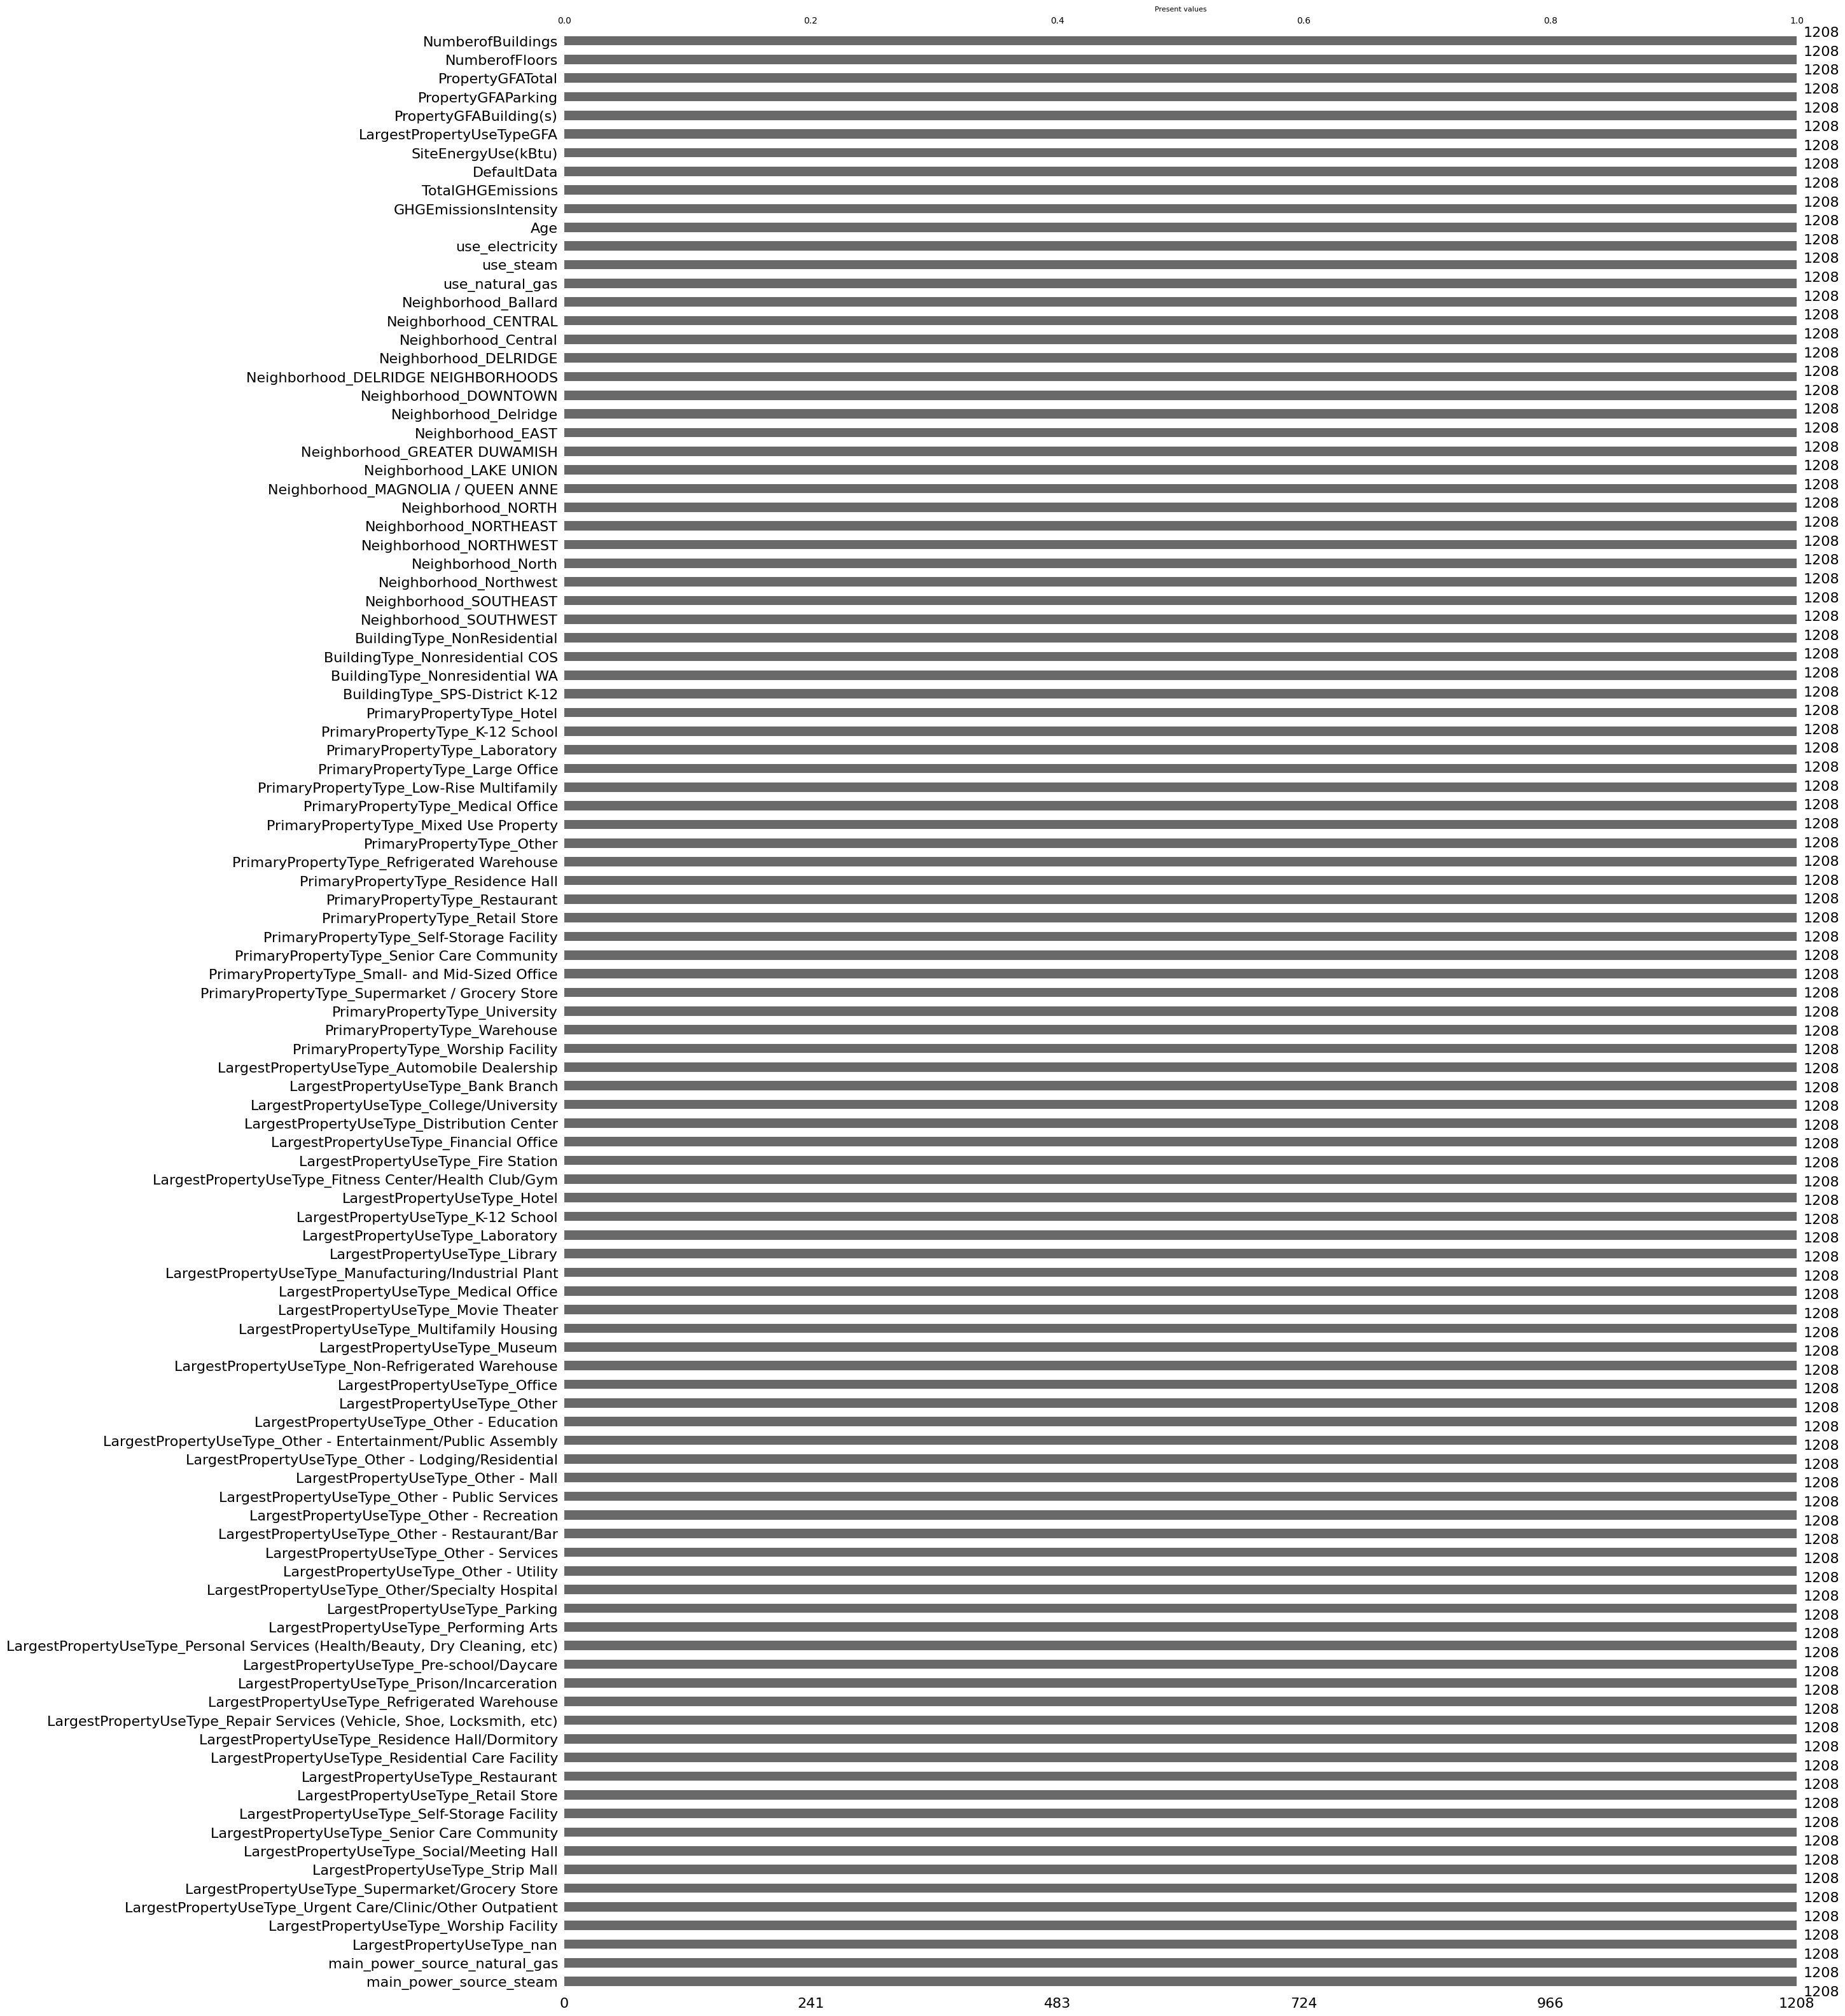

In [22]:
building_consumption_w_drop = building_consumption_w_drop.dropna(axis= 0, how='any')

barchart = msno.bar(building_consumption_w_drop, sort="descending")
barchart.set_title("Present values", fontsize=8)
plt.show()

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [23]:
#print(building_consumption_w_drop.info())

print(building_consumption_w_drop.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1208 entries, 0 to 3375
Columns: 105 entries, NumberofBuildings to main_power_source_steam
dtypes: bool(1), float64(96), int64(8)
memory usage: 992.1 KB
None


In [24]:
# CODE PREPARATION DES FEATURES
X_building = building_consumption_w_drop.drop('SiteEnergyUse(kBtu)', axis=1)
y_building = building_consumption_w_drop['SiteEnergyUse(kBtu)']
X_train, X_test, y_train, y_test = train_test_split(X_building, y_building, test_size=0.2, random_state=42)

X_train.head()
linreg = LinearRegression()
reg = linreg.fit(X_train, y_train)

#print(reg.score(X_train, y_train))

y_predicted = reg.predict(X_test)
#print(y_predicted)
print(y_test)
print(mean_squared_error(y_test, y_predicted)/1e14)
print(mean_absolute_error(y_test, y_predicted)/1e7)
print(r2_score(y_test, y_predicted))


237     2.746561e+06
1840    8.737111e+05
581     4.052720e+06
255     2.933289e+06
1481    7.293972e+05
            ...     
864     4.644178e+06
953     1.128179e+06
2187    2.502081e+06
2583    9.171003e+05
990     1.906385e+06
Name: SiteEnergyUse(kBtu), Length: 242, dtype: float64
0.012135067408475971
0.08220184845809296
0.7760807660829497


<Axes: xlabel='SiteEnergyUse(kBtu)', ylabel='Density'>

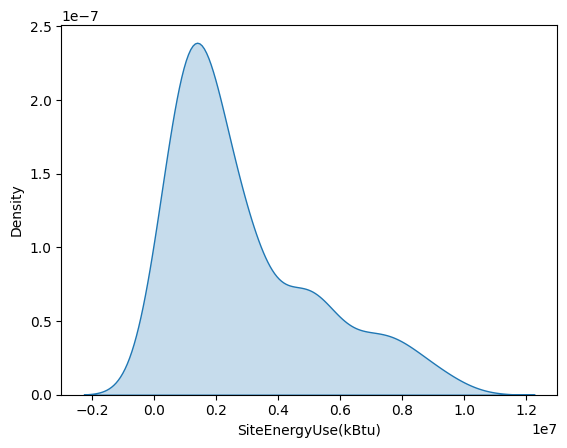

In [25]:
sns.kdeplot(x=y_test, fill=True)

<Axes: xlabel='SiteEnergyUse(kBtu)'>

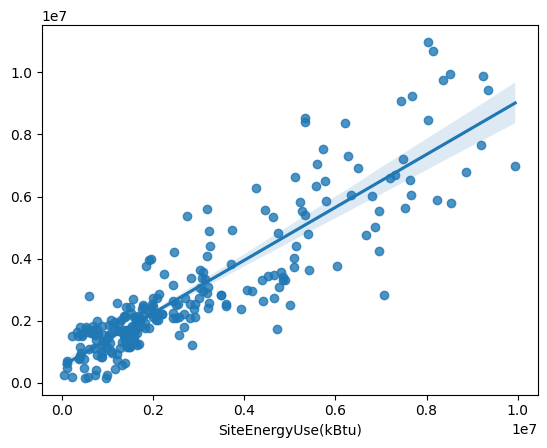

In [194]:
sns.regplot(x=y_test, y=y_predicted)


### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [288]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE